In [102]:
from keras.models import Sequential
from keras.layers import Dense
from keras.activations import relu
from keras.losses import MeanSquaredError

import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

In [103]:
from keras.datasets import boston_housing

(X_train,y_train),(X_test, y_test) = boston_housing.load_data()
X_train = pd.DataFrame(X_train)
X_train

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.23247,0.0,8.14,0.0,0.5380,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72
1,0.02177,82.5,2.03,0.0,0.4150,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11
2,4.89822,0.0,18.10,0.0,0.6310,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26
3,0.03961,0.0,5.19,0.0,0.5150,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01
4,3.69311,0.0,18.10,0.0,0.7130,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,0.21977,0.0,6.91,0.0,0.4480,5.602,62.0,6.0877,3.0,233.0,17.9,396.90,16.20
400,0.16211,20.0,6.96,0.0,0.4640,6.240,16.3,4.4290,3.0,223.0,18.6,396.90,6.59
401,0.03466,35.0,6.06,0.0,0.4379,6.031,23.3,6.6407,1.0,304.0,16.9,362.25,7.83
402,2.14918,0.0,19.58,0.0,0.8710,5.709,98.5,1.6232,5.0,403.0,14.7,261.95,15.79


In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train

array([[-0.27224633, -0.48361547, -0.43576161, ...,  1.14850044,
         0.44807713,  0.8252202 ],
       [-0.40342651,  2.99178419, -1.33391162, ..., -1.71818909,
         0.43190599, -1.32920239],
       [ 0.1249402 , -0.48361547,  1.0283258 , ...,  0.78447637,
         0.22061726, -1.30850006],
       ...,
       [-0.40202987,  0.99079651, -0.7415148 , ..., -0.71712291,
         0.07943894, -0.67776904],
       [-0.17292018, -0.48361547,  1.24588095, ..., -1.71818909,
        -0.98764362,  0.42083466],
       [-0.40422614,  2.04394792, -1.20161456, ..., -1.30866202,
         0.23317118, -1.15392266]], shape=(404, 13))

In [121]:
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(16, activation="relu"),
    Dense(1)
])
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

model.summary()

/Users/nurma/vscode_projects/data_projects/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 32)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 993 (3.88 KB)

 Trainable params: 993 (3.88 KB)

 Non-trainable params: 0 (0.00 B)

In [122]:
history = model.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 620.2157 - mae: 23.0635 - val_loss: 645.6708 - val_mae: 23.6345
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 608.3291 - mae: 22.8038 - val_loss: 634.5764 - val_mae: 23.3932
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 597.8674 - mae: 22.5674 - val_loss: 624.2896 - val_mae: 23.1620
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 588.1915 - mae: 22.3388 - val_loss: 614.9465 - val_mae: 22.9457
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 579.2736 - mae: 22.1277 - val_loss: 606.1649 - val_mae: 22.7362
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 570.8479 - mae: 21.9165 - val_loss: 597.5995 - val_mae: 22.5220
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 562.5222 - mae: 21.6992 - val_loss: 588.7540 - val_mae: 22.2941
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 553.4208 - mae: 21.4611 - val_loss: 579.2496 - val_mae: 22.0488
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2

In [123]:
history.history

{'loss': [620.2156982421875,
  608.3291015625,
  597.8673706054688,
  588.1914672851562,
  579.2735595703125,
  570.847900390625,
  562.522216796875,
  553.4208374023438,
  543.9968872070312,
  533.446533203125,
  521.7716064453125,
  508.2329406738281,
  493.28851318359375,
  475.47149658203125,
  456.4925231933594,
  434.7861328125,
  411.5164794921875,
  385.8473815917969,
  357.6016540527344,
  325.5762634277344,
  292.0459289550781,
  259.00238037109375,
  225.0303955078125,
  192.75173950195312,
  163.70089721679688,
  136.95591735839844,
  116.6816635131836,
  99.65556335449219,
  87.50028991699219,
  78.0766372680664,
  70.77188110351562,
  65.03977966308594,
  59.892311096191406,
  55.07953643798828,
  50.85572052001953,
  47.240562438964844,
  44.117549896240234,
  41.24335861206055,
  38.92898941040039,
  36.76620101928711,
  34.78914260864258,
  33.17121505737305,
  31.718942642211914,
  30.474021911621094,
  29.393932342529297,
  28.30278968811035,
  27.401639938354492,
  

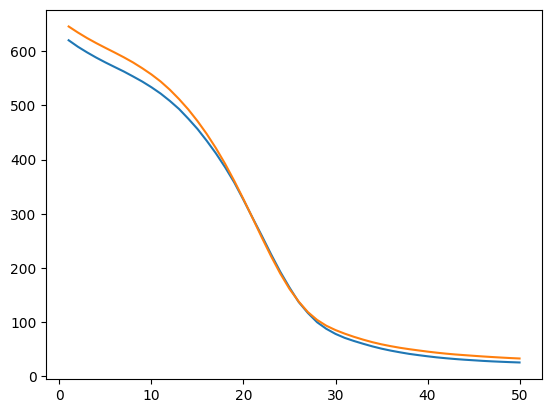

In [124]:
plt.plot(range(1,len(history.history["loss"])+1), history.history["loss"])
plt.plot(range(1,len(history.history["loss"])+1), history.history["val_loss"])
plt.show()

In [125]:
from keras.utils import Sequence

class DataGenerator(Sequence):
    def __init__(self, data, label, batch_size=32):
        self.data = data
        self.label = label
        self.batch_size = batch_size
    
    def __len__(self):
        return int(np.round(len(self.data)/self.batch_size))
    
    def __getitem__(self, index):
        X = self.data[index * self.batch_size : (index + 1) * self.batch_size]
        y = self.label[index * self.batch_size : (index + 1) * self.batch_size]

        return X, y

In [126]:
train_datagen = DataGenerator(X_train, y_train)
test_datagen = DataGenerator(X_test, y_test)

In [138]:
history = model.fit(train_datagen, epochs=50, validation_data=test_datagen)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.1151 - mae: 1.3001 - val_loss: 10.5445 - val_mae: 2.2879
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.0917 - mae: 1.2921 - val_loss: 10.6673 - val_mae: 2.3260
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.1246 - mae: 1.2939 - val_loss: 10.5261 - val_mae: 2.2950
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.0914 - mae: 1.2990 - val_loss: 10.6581 - val_mae: 2.3060
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.1491 - mae: 1.2968 - val_loss: 10.6943 - val_mae: 2.3412
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - loss: 3.1577 - mae: 1.3215 - val_loss: 10.5682 - val_mae: 2.2947
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - loss: 3.1997 - mae: 1.3289 - val_loss: 10.6051 - val_mae: 2.3068
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 960us/step - loss: 3.1028 - mae: 1.3008 - val_loss: 10.4816 - val_mae: 2.2995
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 950us/step - loss

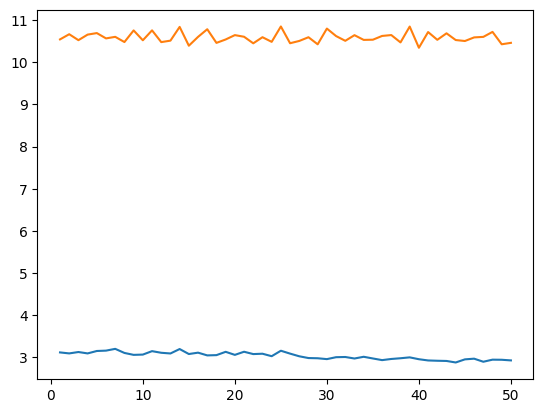

In [141]:
plt.plot(range(1,len(history.history["loss"])+1), history.history["loss"])
plt.plot(range(1,len(history.history["loss"])+1), history.history["val_loss"])
plt.show()

In [129]:
from keras import callbacks

model_checkpoint = callbacks.ModelCheckpoint(
    filepath="model_best_{epoch}.h5",
    monitor="val_loss",
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode="auto",
    save_freq="epoch"
)

In [140]:
model.fit(train_datagen, callbacks=model_checkpoint, epochs=10, validation_data=test_datagen)

Epoch 1/10


 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2790 - mae: 0.9522
Epoch 1: val_loss did not improve from 10.38476
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.8690 - mae: 1.2478 - val_loss: 10.5368 - val_mae: 2.2783
Epoch 2/10
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.8674 - mae: 1.2549
Epoch 2: val_loss did not improve from 10.38476
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.8831 - mae: 1.2440 - val_loss: 10.6161 - val_mae: 2.3328
Epoch 3/10
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4603 - mae: 1.1358
Epoch 3: val_loss did not improve from 10.38476
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.9123 - mae: 1.2562 - val_loss: 10.6475 - val_mae: 2.3138
Epoch 4/10
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4867 - mae: 1.1632
Epoch 4: val_loss did not improve from 10.38476
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.8280 - mae: 1.2354 - val_loss: 10.4124 - val_mae: 2.2860
Epoch 5/10
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5344 - mae: 1.0496

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.7933 - mae: 1.2321 - val_loss: 10.3140 - val_mae: 2.2755
Epoch 7/10
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8664 - mae: 1.3650
Epoch 7: val_loss did not improve from 10.31402
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.8467 - mae: 1.2408 - val_loss: 10.5475 - val_mae: 2.2937
Epoch 8/10
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.5909 - mae: 1.7147
Epoch 8: val_loss did not improve from 10.31402
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.7978 - mae: 1.2282 - val_loss: 10.5064 - val_mae: 2.3080
Epoch 9/10
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3282 - mae: 0.9560
Epoch 9: val_loss did not improve from 10.31402
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.7800 - mae: 1.2151 - val_loss: 10.3641 - val_mae: 2.2815
Epoch 10/10
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2584 - mae: 1.1180
Epoch 10: val_loss did not improve from 10.31402
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.7849 - mae: 1.225

In [145]:
model_earlystopping = callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=3,
    # baseline=0.006,
    verbose=1,
    mode="auto",
    restore_best_weights=True
)

In [149]:
model.fit(train_datagen, validation_data=test_datagen, epochs=10, callbacks=model_earlystopping)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.7919 - mae: 1.2245 - val_loss: 10.4583 - val_mae: 2.2618
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.7088 - mae: 1.2053 - val_loss: 10.7883 - val_mae: 2.3332
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.7653 - mae: 1.2202 - val_loss: 10.5238 - val_mae: 2.3018
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [156]:
model_reduce = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.1,
    patience=2,
    verbose=1,
    mode="auto",
    min_delta=0,
    cooldown=0,
    min_lr=1e-10,
)


In [159]:
model.compile(optimizer="adam", loss="mse", metrics=["mae"])


In [160]:

model.fit(train_datagen, validation_data=test_datagen, epochs=50, callbacks=model_reduce)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.8571 - mae: 1.2267 - val_loss: 10.2924 - val_mae: 2.2436 - learning_rate: 0.0010
Epoch 2/50
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1970 - mae: 0.9040
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.8489 - mae: 1.2499 - val_loss: 10.9383 - val_mae: 2.3517 - learning_rate: 0.0010
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.7191 - mae: 1.2068 - val_loss: 10.8057 - val_mae: 2.3355 - learning_rate: 1.0000e-04
Epoch 4/50
 1/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4972 - mae: 1.3141
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6662 - mae: 1.1956 - val_loss: 10.7007 - val_mae: 2.3267 - learning_rate: 1.0000e-04
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.6523 - mae: 1.1951 - val_loss: 10.6877 - val_mae: 2.3256 - learning_rate: 1.00

In [164]:
a ={1:2,4:8}
a

{1: 2, 4: 8}